# Glielmo synthetic example: linear encoding and Information Imbalance

This notebook treats $x$ as the **model representation** and $y$ as the
**neural representation**. It:

1. generates the nonlinear relation $y=\cos(x_1)$, with an independent second $x$ coordinate;
2. fits the static projections $y\rightarrow\hat{x}$ and
   $x\rightarrow\hat{y}$;
3. computes $R^2$ for both target representations; and
4. computes Information Imbalance between $\hat{x}$ and $\hat{y}$; and
5. repeats the reciprocal OLS and II analysis after replacing the non-zero
   singular values of each fitted map with one.

By default the projections are in-sample. Set `use_cv=True` to assemble
out-of-fold predictions with the configured cross-validation scheme.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# Locate the repository whether Jupyter starts in the project root or scripts folder.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "config.yaml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate config.yaml from the current directory.")
# end if PROJECT_ROOT is None

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)
paths = project_config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from II_analyses.asymmetry_pipeline import (
    run_asymmetry_pipeline,
    summarize_asymmetry_pipeline,
)
from II_analyses.static_encoding import (
    compute_static_prediction_II,
    fit_static_projection,
)
from useful_stuff.general_utils.regression import linear_encoding
from useful_stuff.general_utils.utils import get_triu_perms
from useful_stuff.general_utils.II import InformationImbalance

In [2]:
@dataclass
class Cfg:
    # Synthetic relation.
    n_samples: int = 1000
    x_min: float = 0 #-.5
    x_max: float = 1 #2*np.pi#1.0
    noise_std: float = 0
    y_noise_scale: float = 0.3
    random_seed: int = 0

    # Bidirectional static regression.
    regression_type: str = "lr"
    use_cv: bool = False
    cv_type: str = "kf"
    n_splits: int = 5
    shuffle: bool = True
    singular_value_rtol: float | None = None

    # Information Imbalance. Euclidean distance is appropriate for 1D spaces.
    x_RDM_metric: str = "euclidean"
    y_RDM_metric: str = "euclidean"
    k: int = 1
# EOC


cfg = Cfg()
cfg

Cfg(n_samples=1000, x_min=0, x_max=1, noise_std=0, y_noise_scale=0.3, random_seed=0, regression_type='lr', use_cv=False, cv_type='kf', n_splits=5, shuffle=True, singular_value_rtol=None, x_RDM_metric='euclidean', y_RDM_metric='euclidean', k=1)

## Generate $x$ and $y$

The arrays follow the project convention `(features, samples)`. Here $x$ has
two features, $y$ has one feature, and both share the same observations.

In [18]:
"""
y_func
Generate the noisy nonlinear y representation from x.

INPUT:
    - x: np.ndarray -> one-dimensional x observations
    - rng: np.random.Generator -> seeded random-number generator
    - noise_std: float -> base Gaussian-noise standard deviation
    - noise_scale: float -> multiplier applied to y noise

OUTPUT:
    - y: np.ndarray -> nonlinear y observations
"""
def y_func(x, rng, noise_std, noise_scale):
    noise = rng.normal(0, noise_std, size=len(x)) * noise_scale
    # y_1 = x**2 # * (x - 1) + noise
    y_1 = np.cos(x+.5)
    print()
    
    return y_1[np.newaxis, :] # np.vstack((y_1, y_2)) #  #
# EOF


rng = np.random.default_rng(cfg.random_seed)
latent_u = rng.uniform(cfg.x_min, cfg.x_max, size=cfg.n_samples)
x_values = latent_u + rng.normal(0, cfg.noise_std, size=cfg.n_samples)
y_values = y_func(
    x_values,
    rng=rng,
    noise_std=cfg.noise_std,
    noise_scale=cfg.y_noise_scale,
)

x = x_values[np.newaxis, :]
x_2 = rng.normal(3, 1, size=cfg.n_samples) + rng.normal(-3, 1, size=cfg.n_samples) #np.zeros(noise.shape)
x = np.vstack((x, x_2))
y = y_values # [np.newaxis, :]

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")


x shape: (2, 1000)
y shape: (1, 1000)


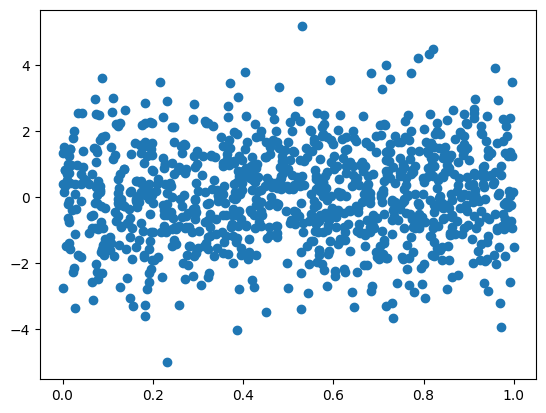

In [19]:
plt.scatter(x[0,:],x_2)

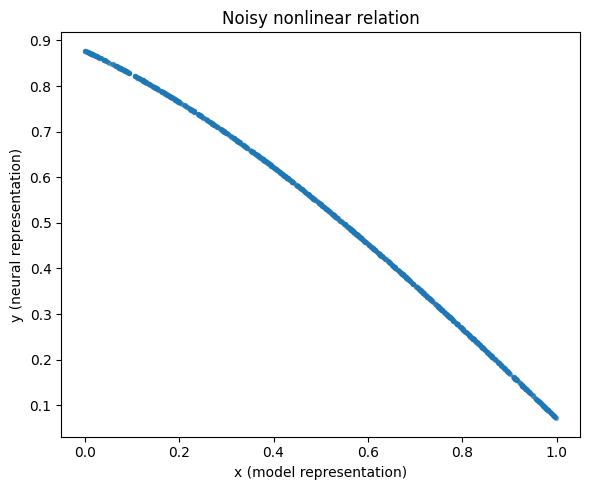

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x[0], y[0], s=8, alpha=0.5)
ax.set_xlabel("x (model representation)")
ax.set_ylabel("y (neural representation)")
ax.set_title("Noisy nonlinear relation")
fig.tight_layout()

## Fit the two static linear projections

`predicted_x` is the $y\rightarrow x$ prediction and `predicted_y` is the
$x\rightarrow y$ prediction. When CV is enabled, both directions use identical
fold assignments and all reported predictions are out of fold.

In [21]:
if cfg.regression_type not in {"lr", "ridge", "lasso", "en"}:
    raise ValueError(f"Unsupported regression_type: {cfg.regression_type}")
# end if cfg.regression_type not in supported types
if cfg.use_cv and cfg.cv_type not in {"loo", "kf"}:
    raise ValueError("Use 'loo' or 'kf' when use_cv=True.")
# end if cfg.use_cv and cfg.cv_type not in supported types

active_cv_type = cfg.cv_type if cfg.use_cv else "same"
y_to_x_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)
x_to_y_encoding = linear_encoding(
    regression_type=cfg.regression_type,
    cv_type=active_cv_type,
    score_type="r2",
    n_splits=cfg.n_splits,
    shuffle=cfg.shuffle,
)

# Reset the seed before each direction so CV uses the same folds.
np.random.seed(cfg.random_seed)
predicted_x, x_r2 = fit_static_projection(
    y,
    x,
    y_to_x_encoding,
    use_cv=cfg.use_cv,
)

np.random.seed(cfg.random_seed)
predicted_y, y_r2 = fit_static_projection(
    x,
    y,
    x_to_y_encoding,
    use_cv=cfg.use_cv,
)

Encoding mode: in-sample
y -> x: R²=0.4979, prediction shape=(2, 1000)
x -> y: R²=0.9930, prediction shape=(1, 1000)
y -> x weight shape: (2, 1)
x -> y weight shape: (1, 2)


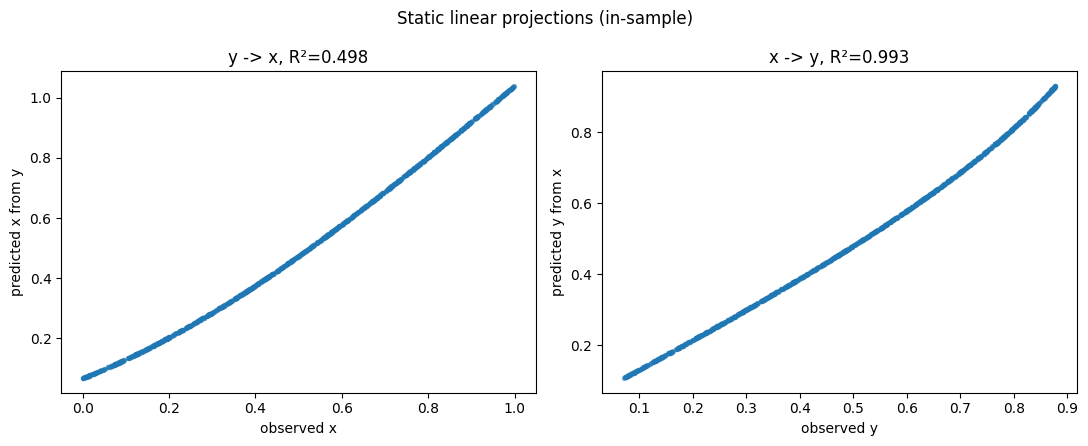

In [22]:
encoding_mode = "out-of-fold" if cfg.use_cv else "in-sample"
print(f"Encoding mode: {encoding_mode}")
print(f"y -> x: R²={np.nanmean(x_r2):.4f}, prediction shape={predicted_x.shape}")
print(f"x -> y: R²={np.nanmean(y_r2):.4f}, prediction shape={predicted_y.shape}")
print(f"y -> x weight shape: {y_to_x_encoding.get_weights().shape}")
print(f"x -> y weight shape: {x_to_y_encoding.get_weights().shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(x[0], predicted_x[0], s=8, alpha=0.5)
axes[0].set_xlabel("observed x")
axes[0].set_ylabel("predicted x from y")
axes[0].set_title(f"y -> x, R²={np.nanmean(x_r2):.3f}")

axes[1].scatter(y[0], predicted_y[0], s=8, alpha=0.5)
axes[1].set_xlabel("observed y")
axes[1].set_ylabel("predicted y from x")
axes[1].set_title(f"x -> y, R²={np.nanmean(y_r2):.3f}")

fig.suptitle(f"Static linear projections ({encoding_mode})")
fig.tight_layout()

Encoding mode: in-sample
y -> x: R²=0.4979, prediction shape=(2, 1000)
x -> y: R²=0.9930, prediction shape=(1, 1000)
y -> x weight shape: (2, 1)
x -> y weight shape: (1, 2)


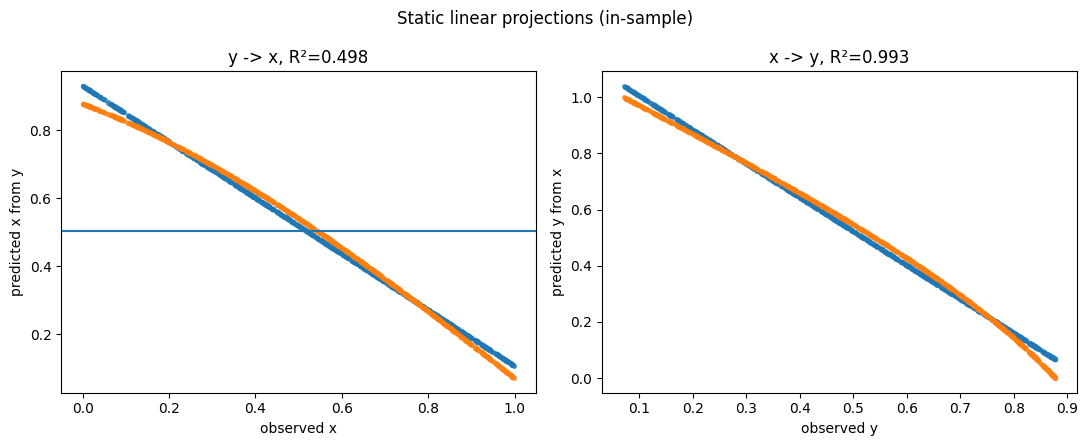

In [23]:
encoding_mode = "out-of-fold" if cfg.use_cv else "in-sample"
print(f"Encoding mode: {encoding_mode}")
print(f"y -> x: R²={np.nanmean(x_r2):.4f}, prediction shape={predicted_x.shape}")
print(f"x -> y: R²={np.nanmean(y_r2):.4f}, prediction shape={predicted_y.shape}")
print(f"y -> x weight shape: {y_to_x_encoding.get_weights().shape}")
print(f"x -> y weight shape: {x_to_y_encoding.get_weights().shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(x[0], predicted_y[0], s=8, alpha=0.5)
axes[0].scatter(x[0], y[0], s=8, alpha=0.5)
axes[0].axhline(np.mean(y[0]))
axes[0].set_xlabel("observed x")
axes[0].set_ylabel("predicted x from y")
axes[0].set_title(f"y -> x, R²={np.nanmean(x_r2):.3f}")

axes[1].scatter(y[0], predicted_x[0], s=8, alpha=0.5)
axes[1].scatter(y[0], x[0], s=8, alpha=0.5)
axes[1].set_xlabel("observed y")
axes[1].set_ylabel("predicted y from x")
axes[1].set_title(f"x -> y, R²={np.nanmean(y_r2):.3f}")

fig.suptitle(f"Static linear projections ({encoding_mode})")
fig.tight_layout()

In [24]:
print(np.var(x))
print(np.var(y))

1.1415762327755945
0.05524675223701285


## Information Imbalance between the predicted spaces

The helper labels its first input as the neural space and its second input as
the model space. Here those inputs are `predicted_y` and `predicted_x`, so `A2B`
is predicted $y\rightarrow x$ and `B2A` is predicted $x\rightarrow y$.

In [25]:
_, predicted_y_to_x_II, predicted_x_to_y_II = compute_static_prediction_II(
    predicted_neural=predicted_y,
    predicted_model=predicted_x,
    neural_RDM_metric=cfg.y_RDM_metric,
    model_RDM_metric=cfg.x_RDM_metric,
    k=cfg.k,
)

print(f"predicted y -> predicted x: II={predicted_y_to_x_II:.6f}")
print(f"predicted x -> predicted y: II={predicted_x_to_y_II:.6f}")

predicted y -> predicted x: II=0.000290
predicted x -> predicted y: II=0.000298


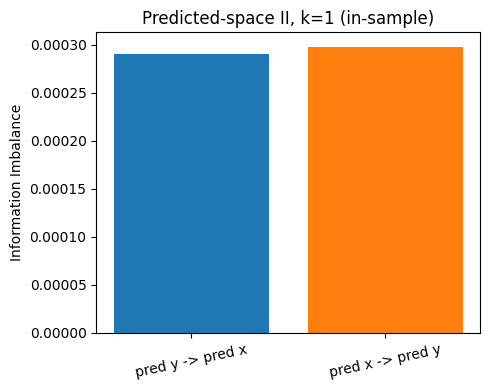

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
directions = ["pred y -> pred x", "pred x -> pred y"]
ii_values = [predicted_y_to_x_II, predicted_x_to_y_II]
ax.bar(directions, ii_values, color=["tab:blue", "tab:orange"])
ax.set_ylabel("Information Imbalance")
ax.set_title(f"Predicted-space II, k={cfg.k} ({encoding_mode})")
ax.tick_params(axis="x", rotation=12)
fig.tight_layout()

In [27]:
residuals_x = x - predicted_x
residuals_y = y - predicted_y


In [28]:
space_names = ["x", "y", "predicted_x", "predicted_y", "residuals_x", "residuals_y"]
all_spaces = [x, y, predicted_x, predicted_y, residuals_x, residuals_y]
space_metrics = [
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
    cfg.x_RDM_metric,
    cfg.y_RDM_metric,
]

# Rows are source spaces and columns are target spaces.
ii_matrix = np.full((len(all_spaces), len(all_spaces)), np.nan)
space_index_pairs = get_triu_perms(list(range(len(all_spaces))))

for idx_A, idx_B in space_index_pairs:
    ii_obj = InformationImbalance(
        signal_RDM_metric=space_metrics[idx_A],
        model_RDM_metric=space_metrics[idx_B],
        k=cfg.k,
    )
    ii_obj.compute_both_RDMs(all_spaces[idx_A], all_spaces[idx_B])
    ii_obj.compute_both_distance_ranks()
    A_to_B_II, B_to_A_II = ii_obj.compute_both_II()

    # A2B is row A -> column B; B2A occupies the transposed position.
    ii_matrix[idx_A, idx_B] = A_to_B_II
    ii_matrix[idx_B, idx_A] = B_to_A_II
# end for idx_A, idx_B in space_index_pairs

ii_table = pd.DataFrame(ii_matrix, index=space_names, columns=space_names)
ii_table.index.name = "source"
ii_table.columns.name = "target"

# Each cell contains II(row source -> column target); self-pairs are blank.
ii_table.style.format(precision=3, na_rep="--").background_gradient(
    cmap="viridis",
    axis=None,
    vmin=0,
    vmax=1,
).set_caption("Directional Information Imbalance")


target,x,y,predicted_x,predicted_y,residuals_x,residuals_y
source,,,,,,
x,--,0.104,0.104,0.104,0.010,0.197
y,0.928,--,0.000,0.000,0.988,0.009
predicted_x,0.928,0.000,--,0.000,0.988,0.009
predicted_y,0.920,0.000,0.000,--,0.980,0.009
residuals_x,0.121,0.731,0.731,0.730,--,0.369
residuals_y,0.977,0.545,0.545,0.545,0.996,--


## SVD-normalize the reciprocal OLS maps

This repeats the full-data OLS analysis used in `gaussian_ols_svd_asymmetry`.
For each fitted coefficient matrix $B=U\Sigma V^\top$ (outputs by inputs),
the non-zero singular values are replaced with one:

$$B_{01}=U\Sigma_{01}V^\top, \qquad W_{01}=B_{01}^\top. $$

The row-wise transforms are $\widetilde{x}=x^\top W_{01}^{x\to y}$ and
$\widetilde{y}=y^\top W_{01}^{y\to x}$. Numerical null directions remain
zero, so the fitted rank is preserved while axis-specific regression gains
are removed. Because $x$ has two features and $y$ has one, $\widetilde{x}$
has one feature and $\widetilde{y}$ has two collinear features.

In [29]:
# The shared pipeline expects samples in rows, unlike this notebook's static spaces.
svd_pipeline = run_asymmetry_pipeline(
    source=x.T,
    target=y.T,
    source_metric=cfg.x_RDM_metric,
    target_metric=cfg.y_RDM_metric,
    k=cfg.k,
    relative_tolerance=cfg.singular_value_rtol,
)
svd_summary = summarize_asymmetry_pipeline(svd_pipeline, "x", "y")
display(svd_summary.style.format({"pooled R2": "{:.6f}", "II": "{:.6f}"}))

# Recover the matrices displayed in the Gaussian example.
svd_directions = (
    (
        "x -> y",
        svd_pipeline["original_fit"]["source_to_target"],
        svd_pipeline["source_svd"],
    ),
    (
        "y -> x",
        svd_pipeline["original_fit"]["target_to_source"],
        svd_pipeline["target_svd"],
    ),
)

for direction, encoding, svd_result in svd_directions:
    coefficient = np.atleast_2d(np.asarray(encoding.get_weights(), dtype=float))
    sigma_01 = np.diag(svd_result["active"].astype(float))
    row_weights = coefficient.T
    normalized_row_weights = svd_result["row_transform"]

    print(f"{direction}: rank={svd_result['rank']}")
    print("singular values:", np.round(svd_result["singular_values"], 6))
    print("Sigma_01:\n", sigma_01)
    print(f"W, shape {row_weights.shape}:\n", np.round(row_weights, 6))
    print(
        f"W_01, shape {normalized_row_weights.shape}:\n",
        np.round(normalized_row_weights, 6),
    )
    print()
# end for direction, encoding, svd_result

x_tilde = svd_pipeline["transformed_source"].T
y_tilde = svd_pipeline["transformed_target"].T
print(f"x_tilde shape: {x_tilde.shape}; y_tilde shape: {y_tilde.shape}")

# The rectangular transforms exchange the output dimensionalities of the maps.
assert x_tilde.shape == (y.shape[0], cfg.n_samples)
assert y_tilde.shape == (x.shape[0], cfg.n_samples)
assert svd_pipeline["source_svd"]["rank"] == np.linalg.matrix_rank(
    svd_pipeline["source_svd"]["row_transform"]
)
assert svd_pipeline["target_svd"]["rank"] == np.linalg.matrix_rank(
    svd_pipeline["target_svd"]["row_transform"]
)


,stage,direction,R2 per output,pooled R2,II
0,original,x -> y,[0.993024],0.993024,0.104296
1,original,y -> x,"[0.993023, 0.002678]",0.039368,0.927768
2,Sigma^-1 normalized,x -> y,"[0.993024, 0.993024]",0.993024,0.000290
3,Sigma^-1 normalized,y -> x,[0.993024],0.993024,0.000298


x -> y: rank=1
singular values: [0.823052]
Sigma_01:
 [[1.]]
W, shape (2, 1):
 [[-8.23052e-01]
 [ 5.20000e-05]]
W_01, shape (2, 1):
 [[-1.0e+00]
 [ 6.3e-05]]

y -> x: rank=1
singular values: [1.248102]
Sigma_01:
 [[1.]]
W, shape (1, 2):
 [[-1.206534 -0.319426]]
W_01, shape (1, 2):
 [[-0.966695 -0.25593 ]]

x_tilde shape: (1, 1000); y_tilde shape: (2, 1000)


### Geometry after singular-value binarization

Matched observations keep the same color in every panel. The middle panel
shows the two transformed representations against one another. The last panel
makes the rank-one geometry of the two-dimensional $\widetilde{y}$ explicit.

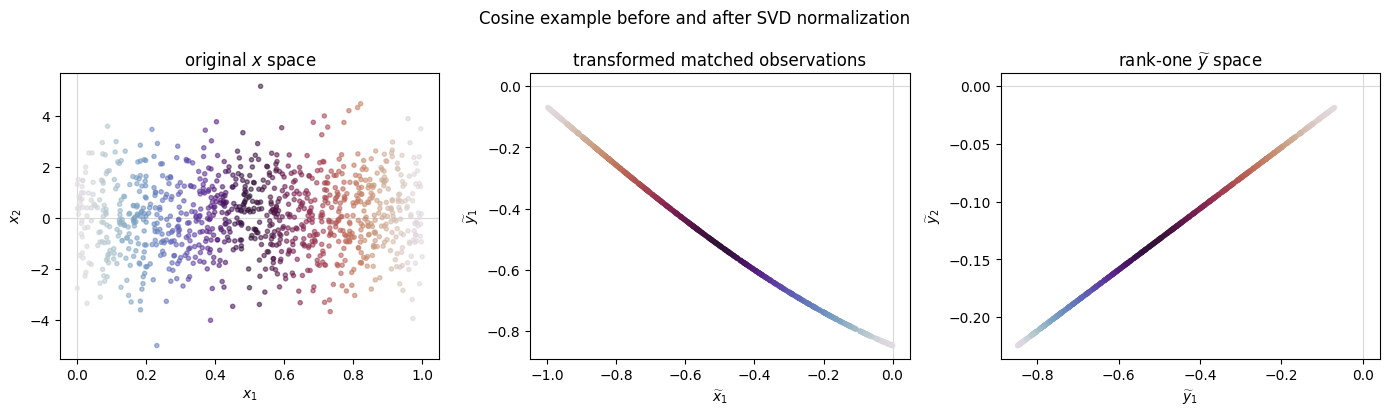

In [30]:
point_color = latent_u
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].scatter(
    x[0], x[1], c=point_color, cmap="twilight", s=9, alpha=0.55
)
axes[0].set(
    xlabel=r"$x_1$", ylabel=r"$x_2$", title=r"original $x$ space"
)

axes[1].scatter(
    x_tilde[0], y_tilde[0], c=point_color, cmap="twilight", s=9, alpha=0.55
)
axes[1].set(
    xlabel=r"$\widetilde{x}_1$",
    ylabel=r"$\widetilde{y}_1$",
    title="transformed matched observations",
)

axes[2].scatter(
    y_tilde[0], y_tilde[1], c=point_color, cmap="twilight", s=9, alpha=0.55
)
axes[2].set(
    xlabel=r"$\widetilde{y}_1$",
    ylabel=r"$\widetilde{y}_2$",
    title=r"rank-one $\widetilde{y}$ space",
)

for ax in axes:
    ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
    ax.axvline(0, color="0.85", linewidth=0.8, zorder=0)
# end for ax in axes

fig.suptitle("Cosine example before and after SVD normalization")
fig.tight_layout()


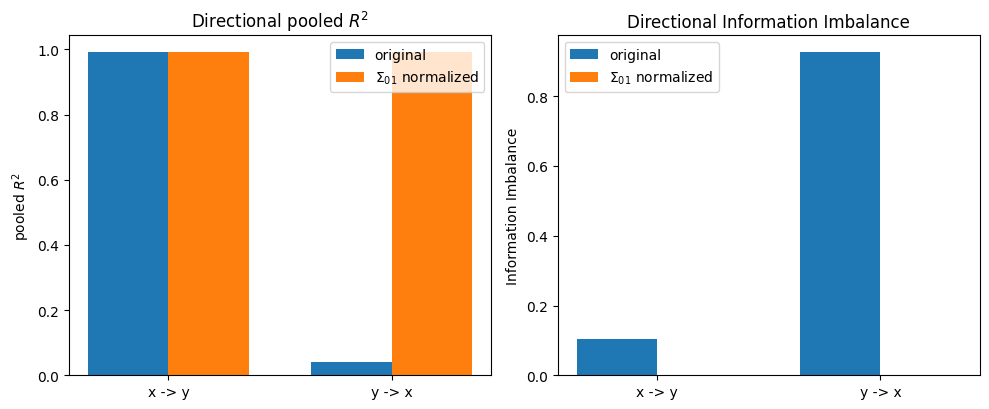

In [31]:
# Compare directional asymmetry before and after the reciprocal transforms.
original_metrics = svd_summary[svd_summary["stage"] == "original"]
normalized_metrics = svd_summary[
    svd_summary["stage"] == "Sigma^-1 normalized"
]
direction_labels = ["x -> y", "y -> x"]
bar_positions = np.arange(len(direction_labels))
bar_width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, metric_name, ylabel in (
    (axes[0], "pooled R2", r"pooled $R^2$"),
    (axes[1], "II", "Information Imbalance"),
):
    ax.bar(
        bar_positions - bar_width / 2,
        original_metrics[metric_name],
        width=bar_width,
        label="original",
    )
    ax.bar(
        bar_positions + bar_width / 2,
        normalized_metrics[metric_name],
        width=bar_width,
        label=r"$\Sigma_{01}$ normalized",
    )
    ax.set_xticks(bar_positions, direction_labels)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Directional {ylabel}")
    ax.legend()
# end for ax, metric_name, ylabel

fig.tight_layout()


### The two projected spaces

$\widetilde{x}$ is one-dimensional, so it is drawn along a horizontal line.
$\widetilde{y}$ has two coordinates but rank one, so its observations lie on
a line in the two-dimensional output space. Colors identify matched samples.

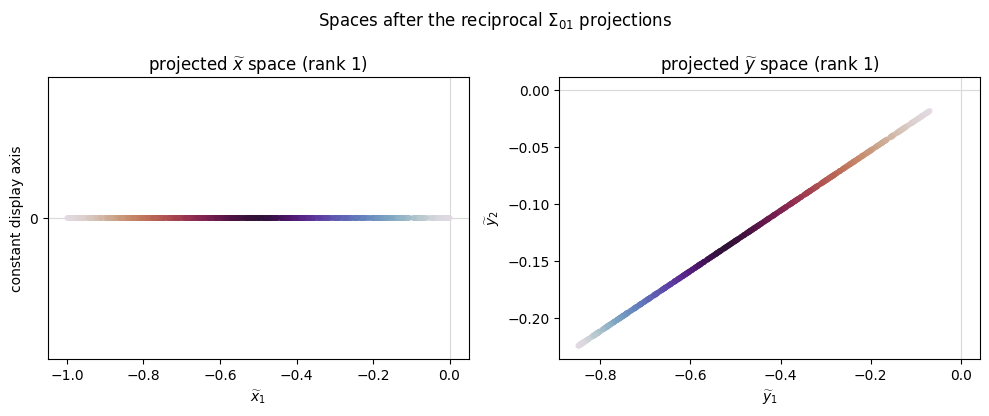

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# x_tilde has one coordinate; zero on the vertical axis exposes its 1D geometry.
axes[0].scatter(
    x_tilde[0],
    np.zeros(cfg.n_samples),
    c=point_color,
    cmap="twilight",
    s=10,
    alpha=0.55,
)
axes[0].set(
    xlabel=r"$\widetilde{x}_1$",
    ylabel="constant display axis",
    title=r"projected $\widetilde{x}$ space (rank 1)",
)
axes[0].set_yticks([0])

# y_tilde has two coordinates whose rank-one structure appears as a line.
axes[1].scatter(
    y_tilde[0],
    y_tilde[1],
    c=point_color,
    cmap="twilight",
    s=10,
    alpha=0.55,
)
axes[1].set(
    xlabel=r"$\widetilde{y}_1$",
    ylabel=r"$\widetilde{y}_2$",
    title=r"projected $\widetilde{y}$ space (rank 1)",
)

for ax in axes:
    ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
    ax.axvline(0, color="0.85", linewidth=0.8, zorder=0)
# end for ax in axes

fig.suptitle(r"Spaces after the reciprocal $\Sigma_{01}$ projections")
fig.tight_layout()
